Dataset shape: (8208, 116)


,DATASET,SERIES_CODE,OBS_MEASURE,COUNTRY,INDICATOR,FREQUENCY,SCALE,DECIMALS_DISPLAYED,FUNCTIONAL_CAT,INT_ACC_ITEM,...,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030
0,IMF.RES:WEO(9.0.0),LIE.LE.A,OBS_VALUE,"Liechtenstein, Principality of","Employed persons, Persons for countries / Inde...",Annual,Millions,Three,NaN,NaN,...,0.041,0.043,0.043,0.044,0.045,0.046,NaN,NaN,NaN,NaN
1,IMF.RES:WEO(9.0.0),CAN.LE.A,OBS_VALUE,Canada,"Employed persons, Persons for countries / Inde...",Annual,Millions,Three,NaN,NaN,...,18.973,19.748,20.341,20.723,21.009,21.080,NaN,NaN,NaN,NaN
2,IMF.RES:WEO(9.0.0),HND.NGDPPC.A,OBS_VALUE,Honduras,"Gross domestic product (GDP), Current prices, ...",Annual,Units,Three,NaN,NaN,...,66813.898,74749.009,80686.569,86300.122,95066.366,100495.041,106338.384,112815.742,119722.508,126957.554
3,IMF.RES:WEO(9.0.0),HND.LP.A,OBS_VALUE,Honduras,"Population, Persons for countries / Index for ...",Annual,Millions,Three,NaN,NaN,...,10.117,10.294,10.475,10.659,10.846,11.037,11.231,11.428,11.629,11.833
4,IMF.RES:WEO(9.0.0),BHS.LP.A,OBS_VALUE,"Bahamas, The","Population, Persons for countries / Index for ...",Annual,Millions,Three,NaN,NaN,...,0.394,0.399,0.404,0.408,0.413,0.417,0.421,0.425,0.429,0.434



=== Logistic Regression ===
              precision    recall  f1-score   support

        High       0.78      0.89      0.83       134
         Low       0.75      0.85      0.80       133
         Mid       0.77      0.56      0.65       133

    accuracy                           0.77       400
   macro avg       0.77      0.77      0.76       400
weighted avg       0.77      0.77      0.76       400



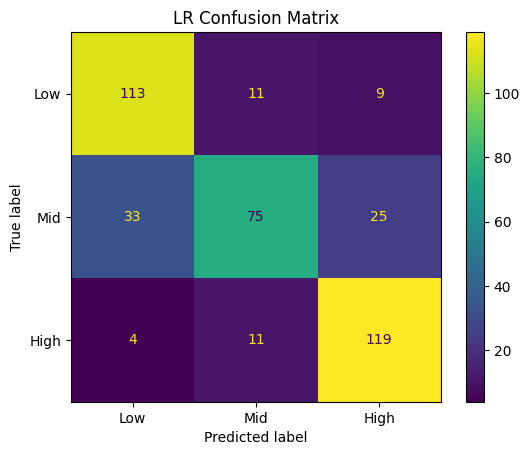


=== Random Forest ===
              precision    recall  f1-score   support

        High       0.96      0.96      0.96       134
         Low       0.78      0.97      0.86       133
         Mid       0.94      0.70      0.80       133

    accuracy                           0.88       400
   macro avg       0.89      0.88      0.87       400
weighted avg       0.89      0.88      0.87       400



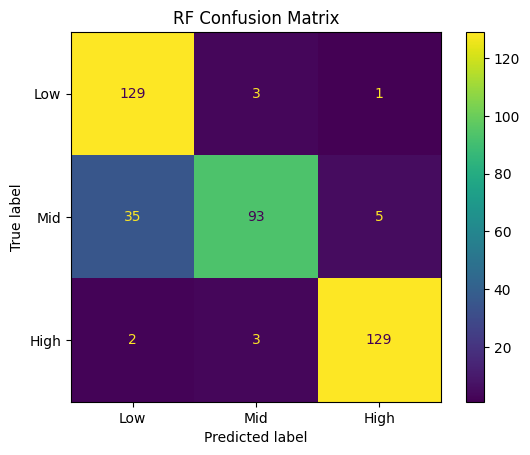

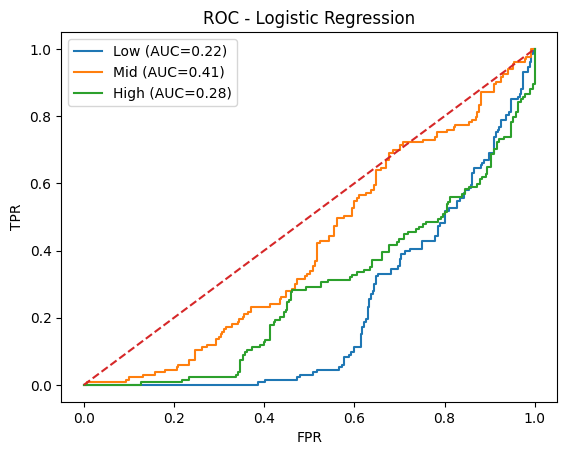

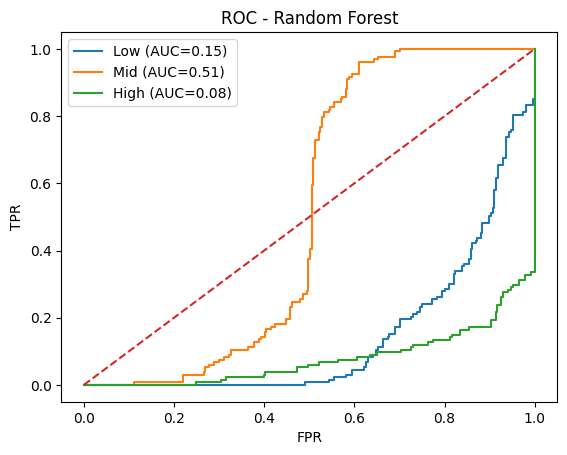

Silhouette: 0.8645912748199636


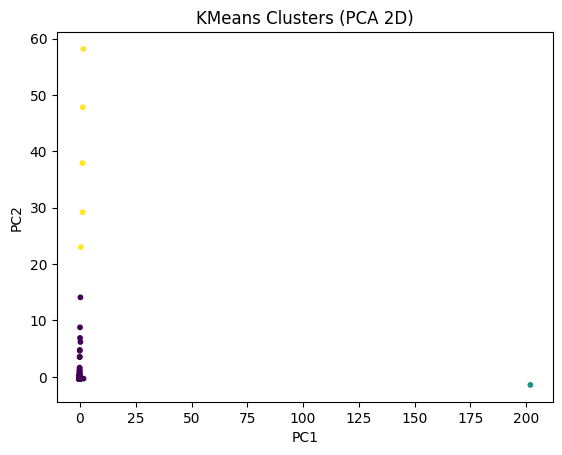

,Model,Accuracy,F1 (macro)
0,Logistic Regression,0.7675,0.760010
1,Random Forest,0.8775,0.874569


In [21]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay,
    roc_curve, auc
)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# 1) Load
DATA_PATH = "dataset_DEFAULT_INTEGRATION_WEO.csv"
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())

# 2) Target
TARGET_COL = None

def choose_numeric_target(data):
    nums = data.select_dtypes(include=[np.number]).columns.tolist()
    if not nums:
        raise ValueError("No numeric columns found.")
    return data[nums].notna().mean().sort_values(ascending=False).index[0]

if TARGET_COL is None:
    TARGET_COL = choose_numeric_target(df)

df_sup = df.dropna(subset=[TARGET_COL]).copy()

# عشان اسرع الكود
df_sup = df_sup.sample(n=min(2000, len(df_sup)), random_state=RANDOM_STATE)

try:
    df_sup["target_class"] = pd.qcut(df_sup[TARGET_COL], q=3, labels=["Low","Mid","High"])
except:
    df_sup["target_class"] = pd.cut(df_sup[TARGET_COL], bins=3, labels=["Low","Mid","High"])

X = df_sup.drop(columns=[TARGET_COL, "target_class"], errors="ignore")
y = df_sup["target_class"].astype(str)

# 3) Preprocessing (fix mixed types)
obj_cols = X.select_dtypes(include=["object"]).columns
X[obj_cols] = X[obj_cols].astype(str).replace({"nan": np.nan, "None": np.nan, "NaN": np.nan})

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

# 4) Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# 5) Supervised 1: Logistic Regression (no grid)
lr = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        solver="saga", max_iter=2000, n_jobs=-1, multi_class="ovr", C=1.0
    ))
])

lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print("\n=== Logistic Regression ===")
print(classification_report(y_test, pred_lr))
ConfusionMatrixDisplay.from_predictions(y_test, pred_lr, labels=["Low","Mid","High"])
plt.title("LR Confusion Matrix")
plt.show()

# 6) Supervised 2: Random Forest (no grid)
rf = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=200, max_depth=20, random_state=RANDOM_STATE, n_jobs=-1
    ))
])

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print(classification_report(y_test, pred_rf))
ConfusionMatrixDisplay.from_predictions(y_test, pred_rf, labels=["Low","Mid","High"])
plt.title("RF Confusion Matrix")
plt.show()

# 7) ROC Curves
classes = ["Low","Mid","High"]
y_bin = label_binarize(y_test, classes=classes)

def plot_roc(model, title):
    probs = model.predict_proba(X_test)
    plt.figure()
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})")
    plt.plot([0,1],[0,1],"--")
    plt.title(title)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.show()

plot_roc(lr, "ROC - Logistic Regression")
plot_roc(rf, "ROC - Random Forest")

# 8) Unsupervised: KMeans (fast)
# للتسريع بعد
X_unsup = preprocess.fit_transform(X.sample(n=min(1000, len(X)), random_state=RANDOM_STATE))

k = 3
kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
labels = kmeans.fit_predict(X_unsup)

print("Silhouette:", silhouette_score(X_unsup, labels))

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_unsup)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=10)
plt.title("KMeans Clusters (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# 9) Summary Table
summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, pred_lr), accuracy_score(y_test, pred_rf)],
    "F1 (macro)": [f1_score(y_test, pred_lr, average="macro"), f1_score(y_test, pred_rf, average="macro")]
})
display(summary)
